In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [6]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [7]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(investor.shape)

(46000, 3)
(90, 5)
(48, 6)
(32778, 13)


# Chart 1: NAV Trend Analysis

In [8]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

## Insight 1

Most mutual fund schemes showed a steady upward NAV trend between 2022 and 2025.

A strong bull market during 2023 resulted in significant NAV appreciation across equity-oriented schemes, while market corrections were visible during parts of 2024.

# Chart 2: AUM Growth by Fund House (2022–2025)


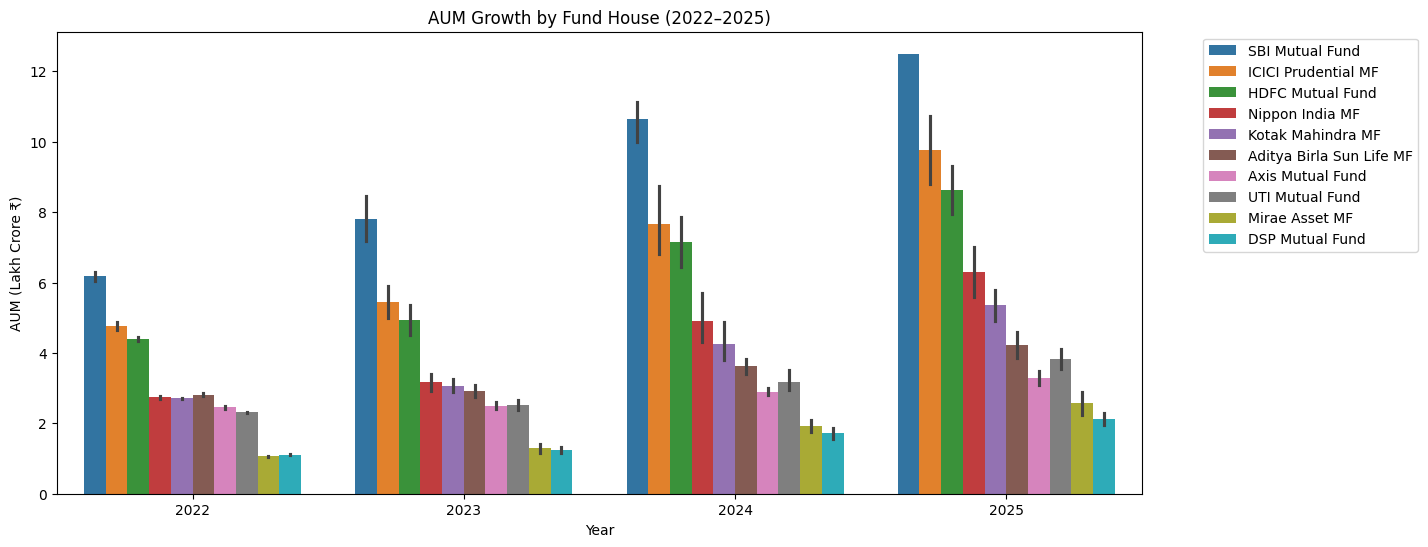

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

## Insight 2

SBI Mutual Fund maintained the highest Assets Under Management throughout the study period and crossed ₹12.5 lakh crore by 2025.

Large AMCs such as SBI, ICICI Prudential, and HDFC consistently dominated industry AUM, reflecting strong investor trust and distribution networks.

# Chart 3: Monthly SIP Inflows Trend

In [10]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)"
)

# Mark highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Peak: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True
)

fig.show()

## Insight 3

Monthly SIP inflows showed strong and consistent growth throughout the study period.

The highest monthly SIP inflow was recorded in December 2025 at approximately ₹31,002 crore, indicating increasing retail investor participation in mutual funds.

## Category Inflow Heatmap

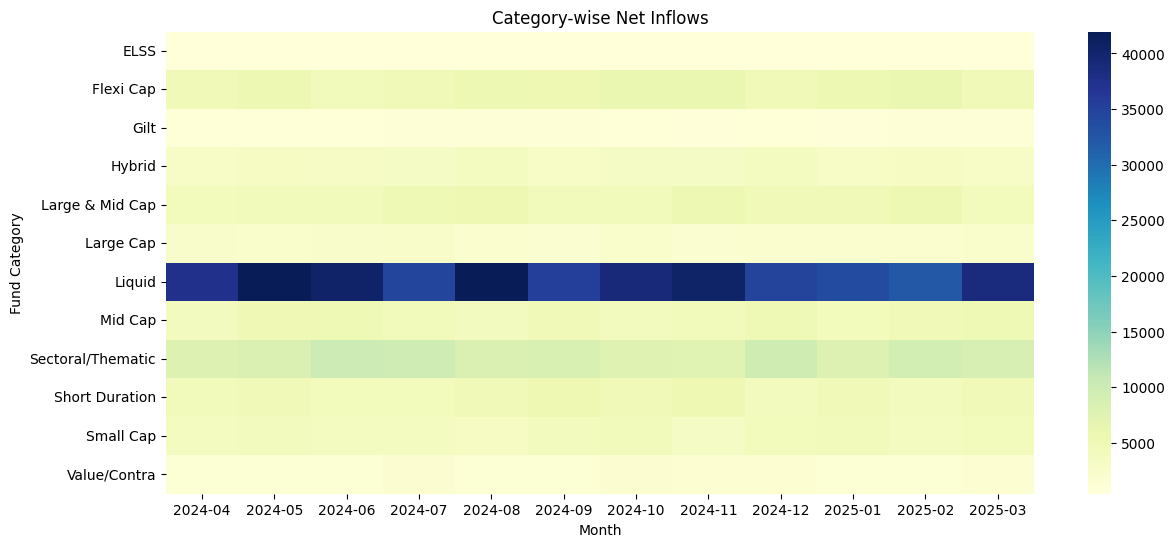

In [12]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

## Insight 4

Flexi Cap, Mid Cap and Small Cap funds consistently attracted strong investor inflows, indicating sustained preference for growth-oriented mutual fund categories.

## Investor Age Group Distribution

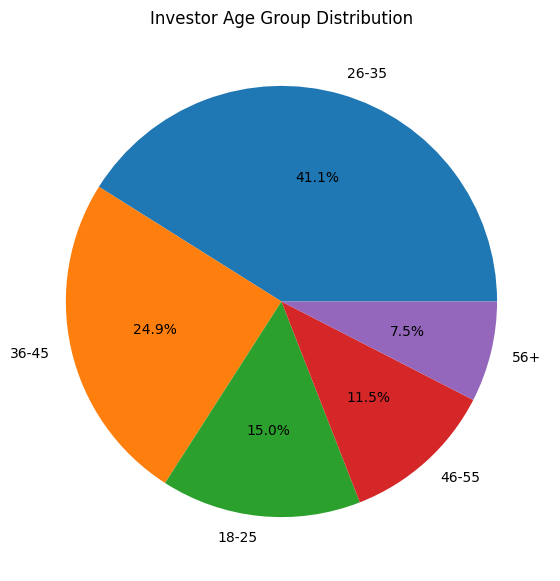

In [16]:
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

## Insight 5

The majority of investors belong to the working-age population, highlighting strong participation from young and middle-aged investors.

## SIP Amount by Age Group (Box Plot)

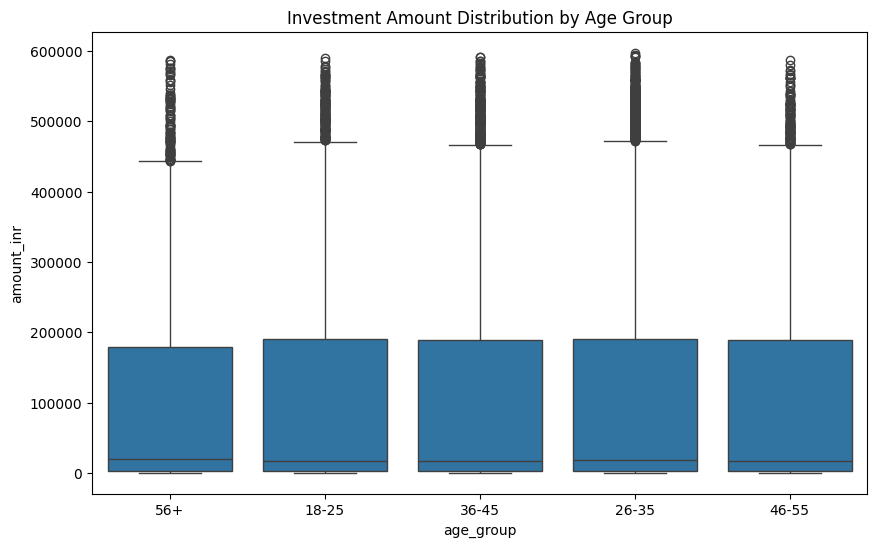

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.show()

## Insight 6

Higher age groups exhibit larger investment amounts, while younger investors demonstrate greater variability in investment behaviour.

## Gender Split

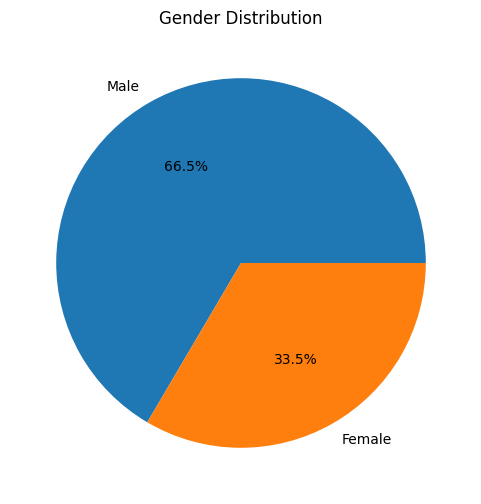

In [18]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

## Insight 7

Male investors contribute a larger share of transactions, though female participation remains significant across fund categories.

 # Chart 8: State-wise Investment Amount

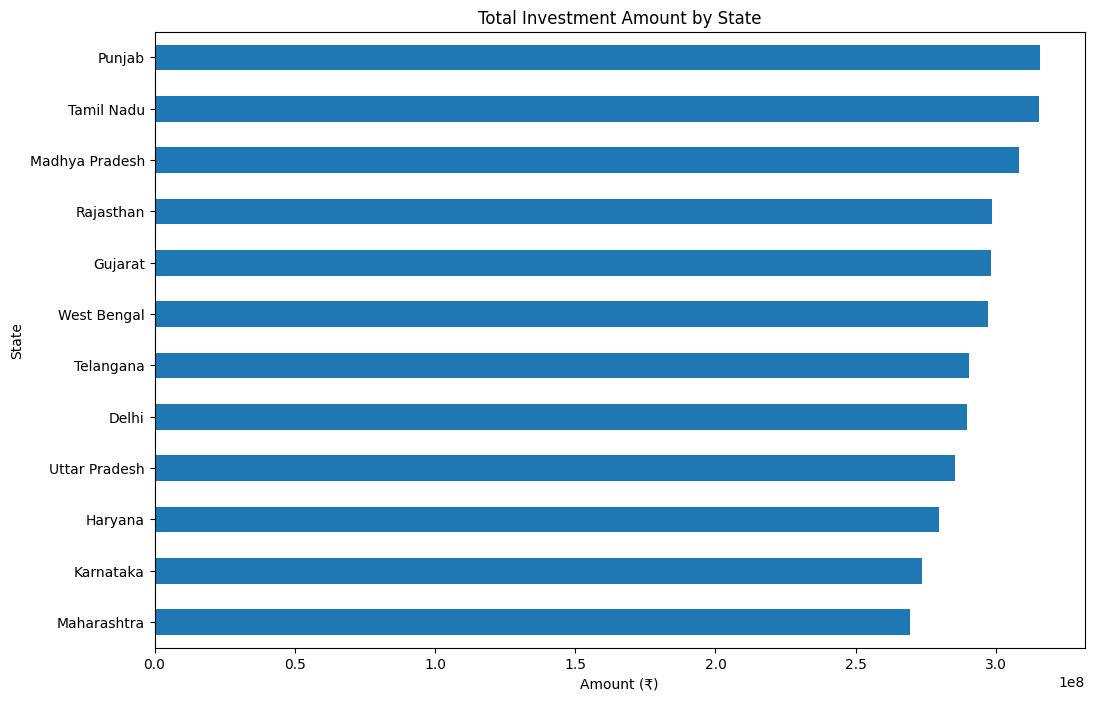

In [19]:
state_amount = (
    investor
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (₹)")
plt.ylabel("State")

plt.show()

## Insight 8

Investment activity is concentrated in a few major states, indicating stronger mutual fund penetration in financially developed regions.

# Chart 9: T30 vs B30 City Distribution

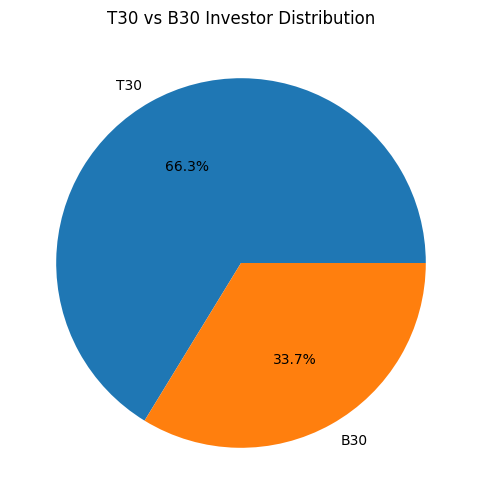

In [20]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

## Insight 9

T30 cities account for a significant share of mutual fund investments, although B30 participation continues to grow steadily.

# Chart 10: Industry Folio Growth

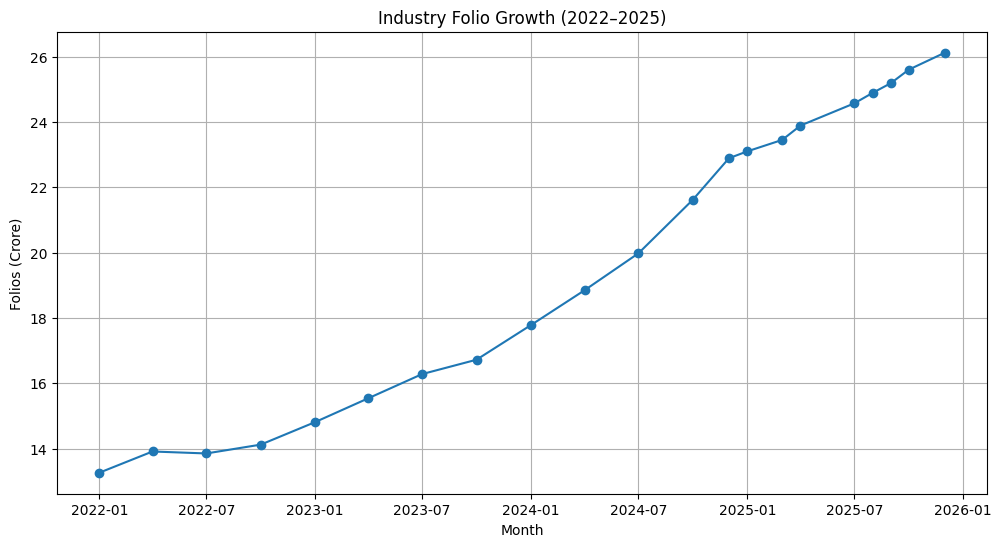

In [21]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

## Insight 10

Industry folios increased substantially from 2022 to 2025, reflecting rising investor participation and broader adoption of mutual funds.

# Chart 11: NAV Return Correlation Matrix

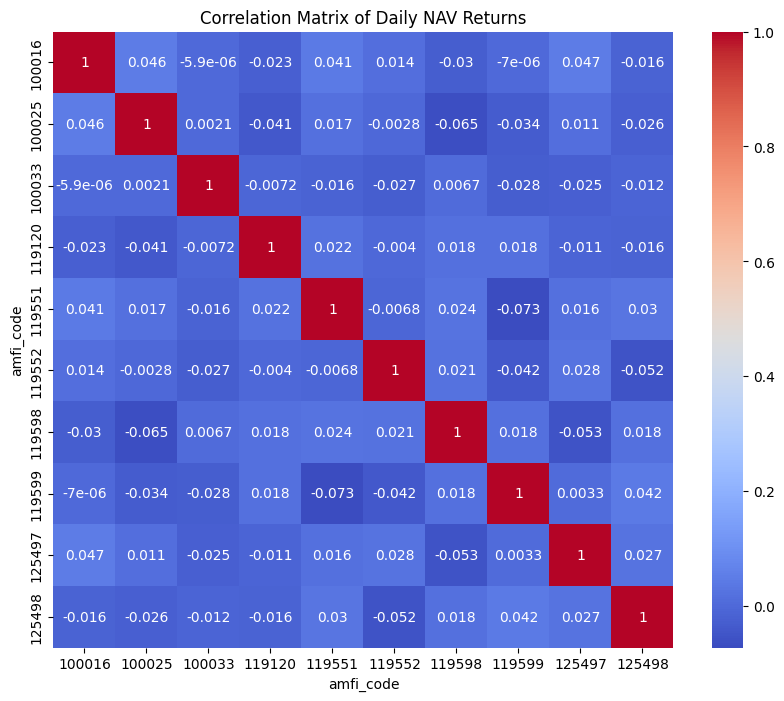

In [22]:
top10 = nav["amfi_code"].unique()[:10]

corr_data = nav[
    nav["amfi_code"].isin(top10)
].copy()

pivot_df = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_df.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.show()

## Insight 11

Most diversified equity funds show strong positive correlations, indicating that broad market movements influence fund performance.

# Chart 12: Sector Allocation Across Equity Funds

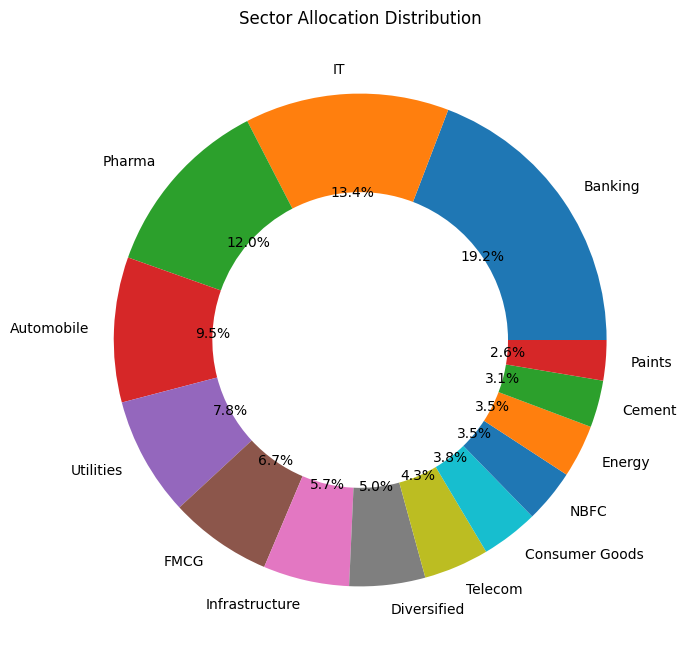

In [23]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    wedgeprops={"width":0.4},
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Distribution")

plt.show()

## Insight 12

Financial Services, IT, and Consumer sectors account for a significant share of portfolio allocations across equity funds.

# Chart 13: Top 10 Funds by AUM

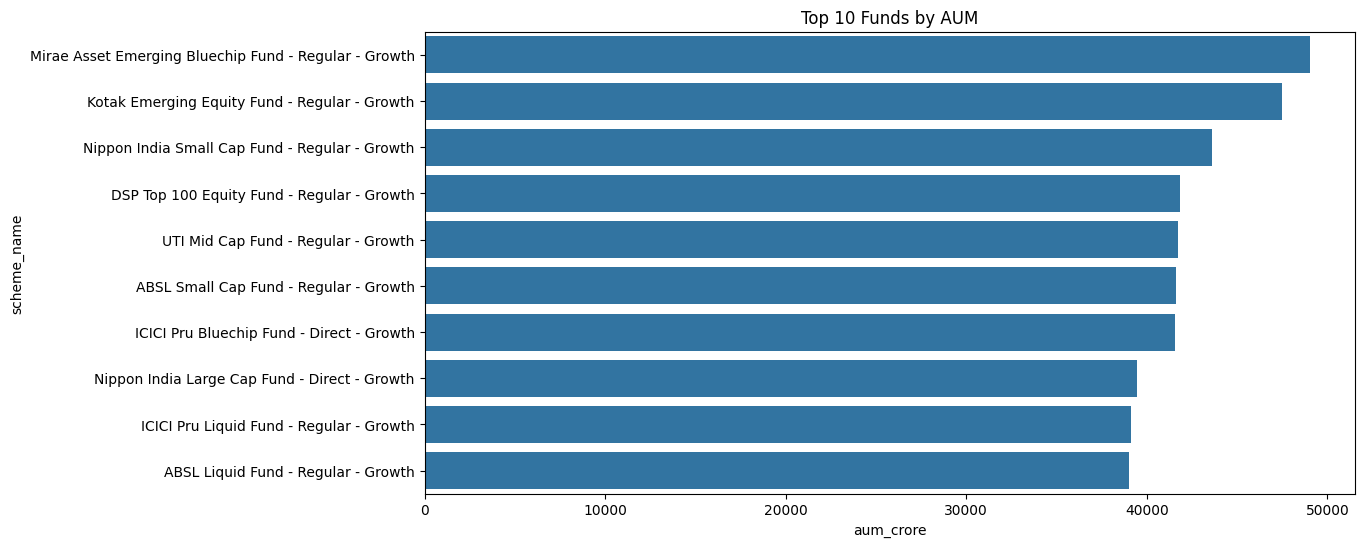

In [24]:
top_funds = performance.nlargest(
    10,
    "aum_crore"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.show()

## Insight 13

A small number of large schemes manage a substantial proportion of industry assets.

# Chart 14: Sharpe Ratio Distribution

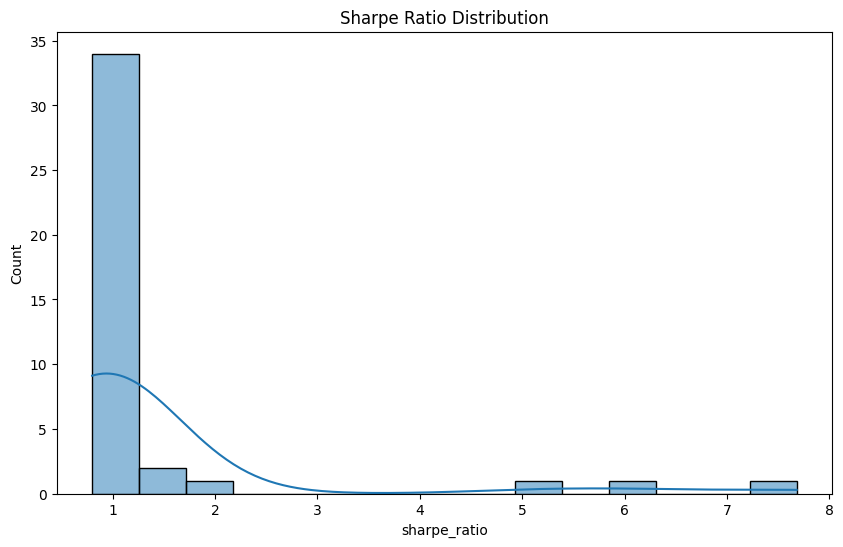

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["sharpe_ratio"],
    bins=15,
    kde=True
)

plt.title("Sharpe Ratio Distribution")

plt.show()

## Insight 14

Most funds exhibit positive risk-adjusted returns, with Sharpe ratios concentrated within a moderate range.

# Chart 15: Expense Ratio Distribution

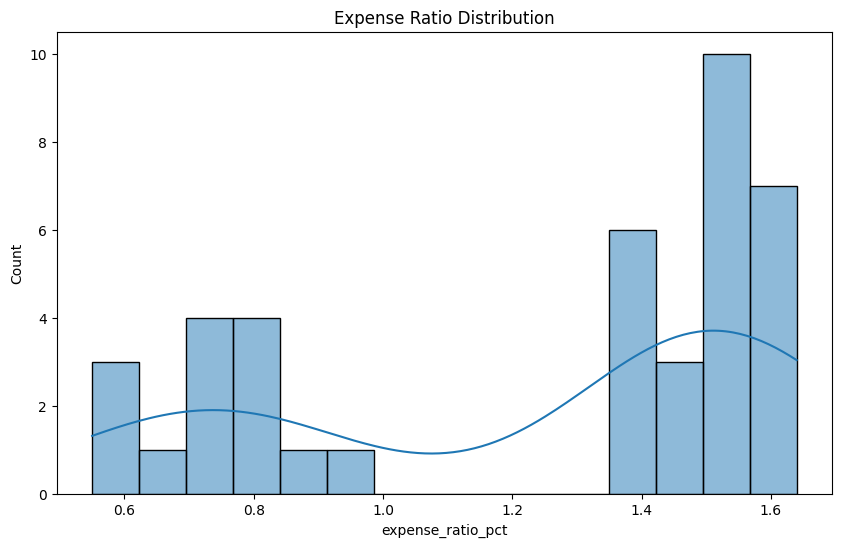

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

## Insight 15

Expense ratios are generally clustered within regulatory norms, with only a few schemes approaching upper limits.

## Category-wise Average Returns,

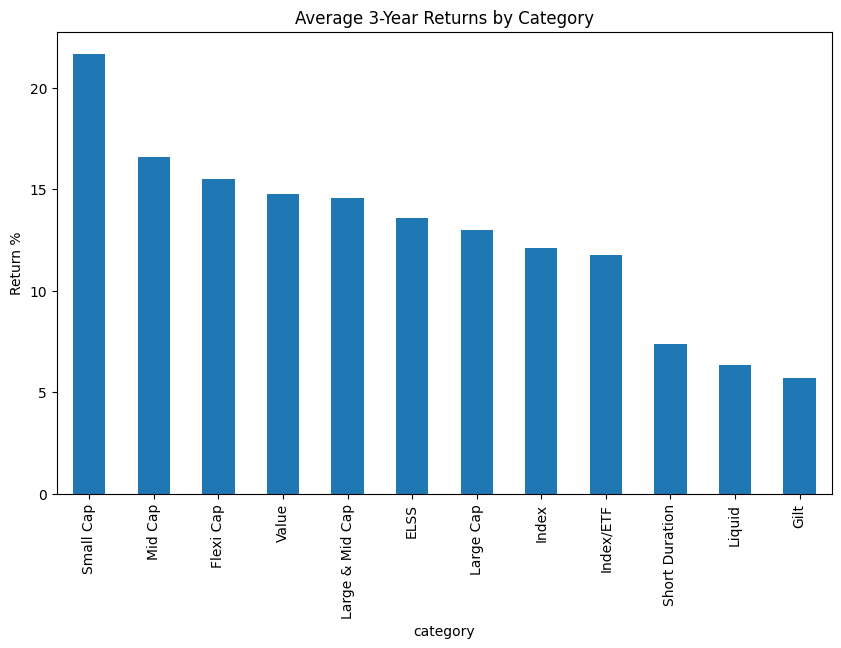

In [27]:
avg_returns = (
    performance
    .groupby("category")["return_3yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

avg_returns.plot(kind="bar")

plt.title("Average 3-Year Returns by Category")

plt.ylabel("Return %")

plt.show()

## Insight 16

Mid Cap and Small Cap categories generated higher average 3-year returns compared to other fund categories, reflecting their stronger growth potential. However, these categories are generally associated with higher volatility and investment risk.